Importing the Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Classification
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Column Transformer
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.impute import SimpleImputer

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    f_regression
)

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Time Series Forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Export
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


Importing the dataset

In [ ]:

df = pd.read_csv("Country-data.csv")

print('\n',df.head())
print('\n',df.shape)
print('\n',df.info())
print('\n',df.describe())

print(df.isnull().sum())


                country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

 (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports  

Data Cleaning and preprocessing

In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())


# IDENTIFY COLUMN TYPES
# Country is categorical

country_names = df['country']

# NUMERICAL FEATURES ONLY
X = df.drop(
    columns=['country']
)

print(X.head())

# Remaining columns are numerical
numerical_cols = [

    'child_mort',
    'exports',
    'health',
    'imports',
    'income',
    'inflation',
    'life_expec',
    'total_fer',
    'gdpp'

]

numerical_cols = X.columns

# NUMERICAL PIPELINE

num_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

# COLUMN TRANSFORMER
preprocessor = ColumnTransformer([
    (
        'num',
        num_pipeline,
        numerical_cols
    )
])

# TRANSFORM DATA
X_scaled = preprocessor.fit_transform(X)
print("Scaled Data Shape")
print(X_scaled.shape)

# APPLY PREPROCESSING
X_processed = preprocessor.fit_transform(df)
print("\nProcessed Data Shape:")
print(X_processed.shape)

Shape of Dataset:
(167, 10)

Duplicate Rows:
0

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
   child_mort  exports  health  imports  income  inflation  life_expec  \
0        90.2     10.0    7.58     44.9    1610       9.44        56.2   
1        16.6     28.0    6.55     48.6    9930       4.49        76.3   
2        27.3     38.4    4.17     31.4   12900      16.10        76.5   
3       119.0     62.3    2.85     42.9    5900      22.40        60.1   
4        10.3     45.5    6.03     58.9   19100       1.44        76.8   

   total_fer   gdpp  
0       5.82    553  
1       1.65   4090  
2       2.89   4460  
3       6.16   3530  
4       2.13  12200  
Scaled Data Shape
(167, 9)

Processed Data Shape:
(167, 9)


Exploratory Data Analysis

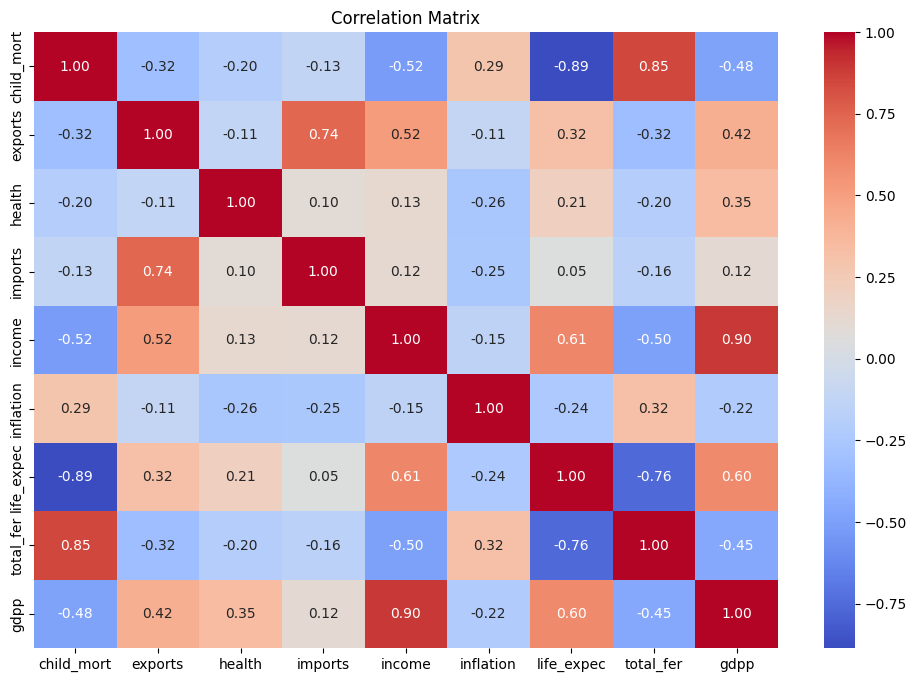

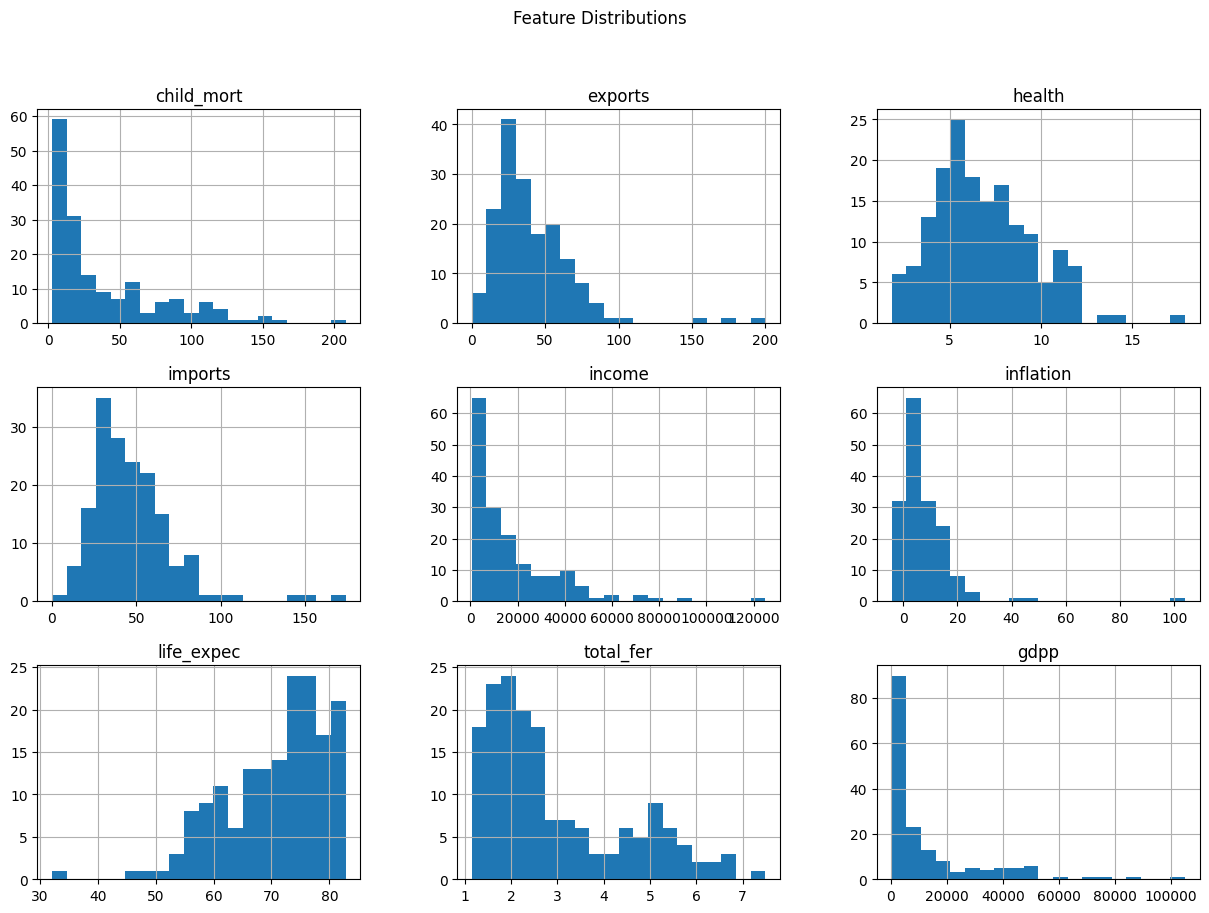

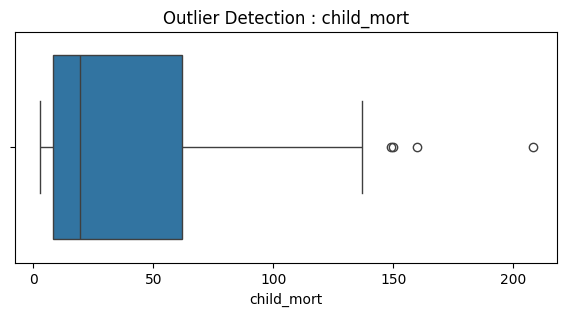

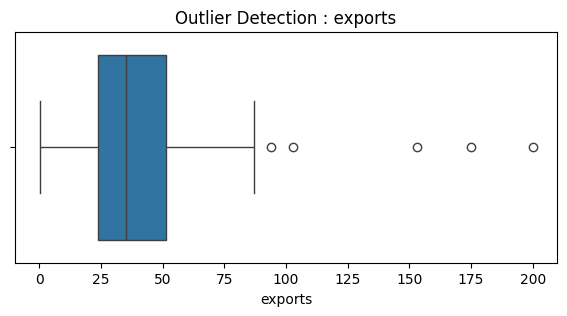

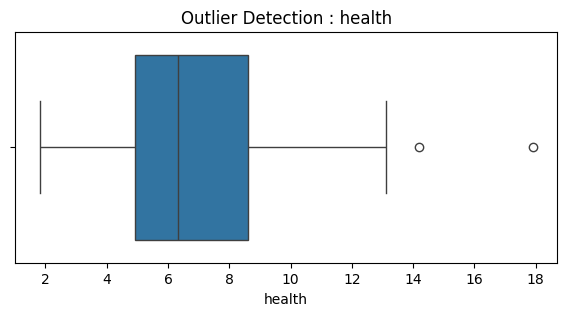

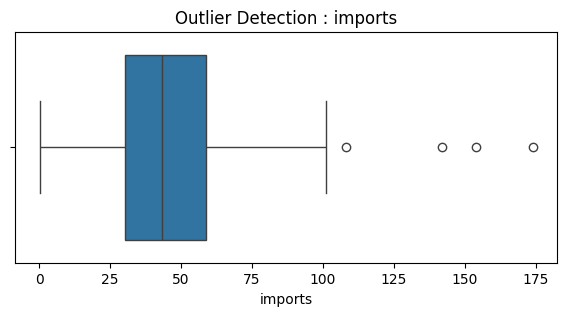

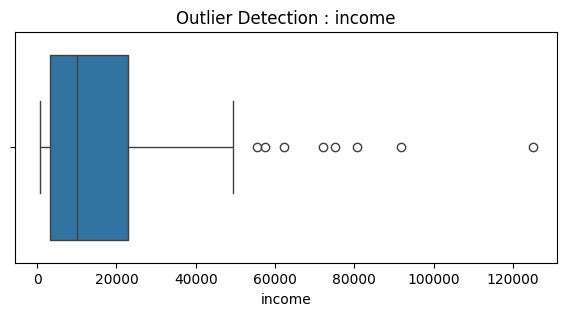

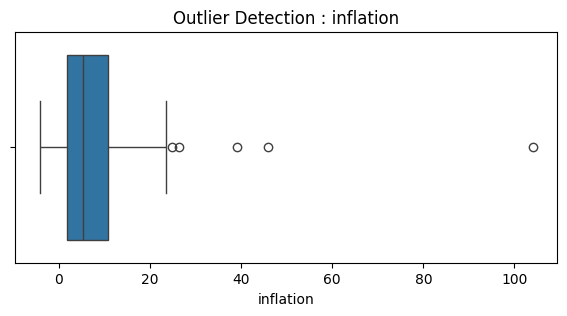

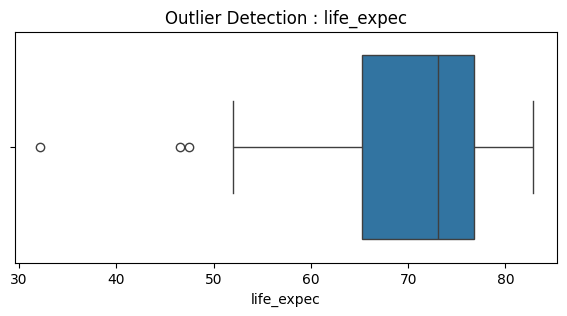

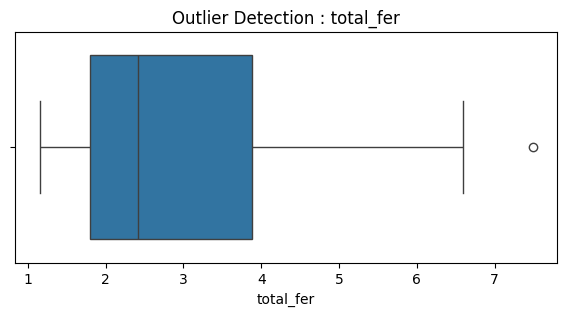

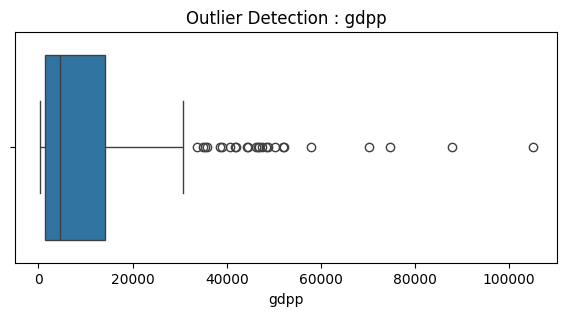

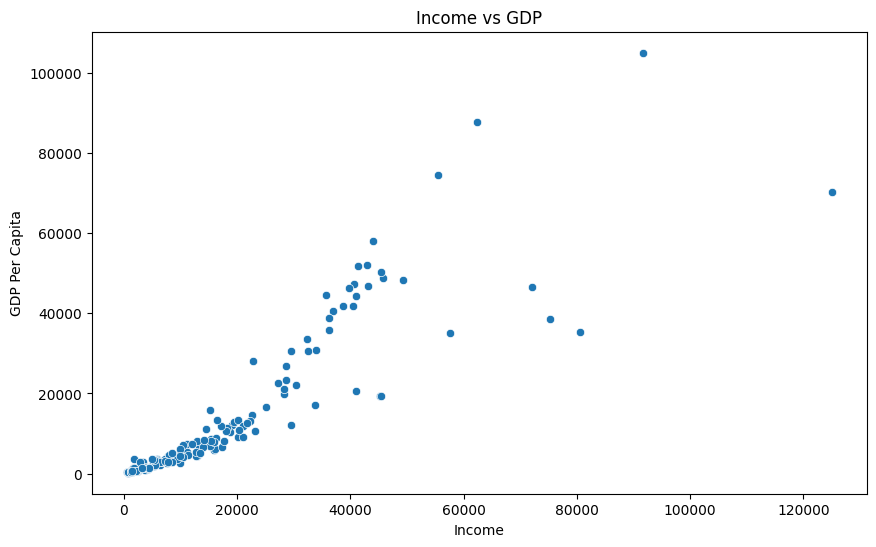

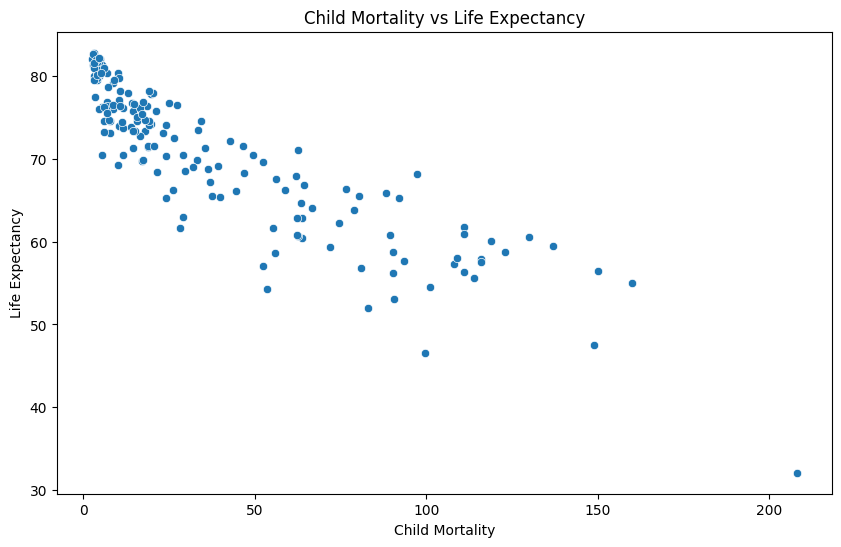

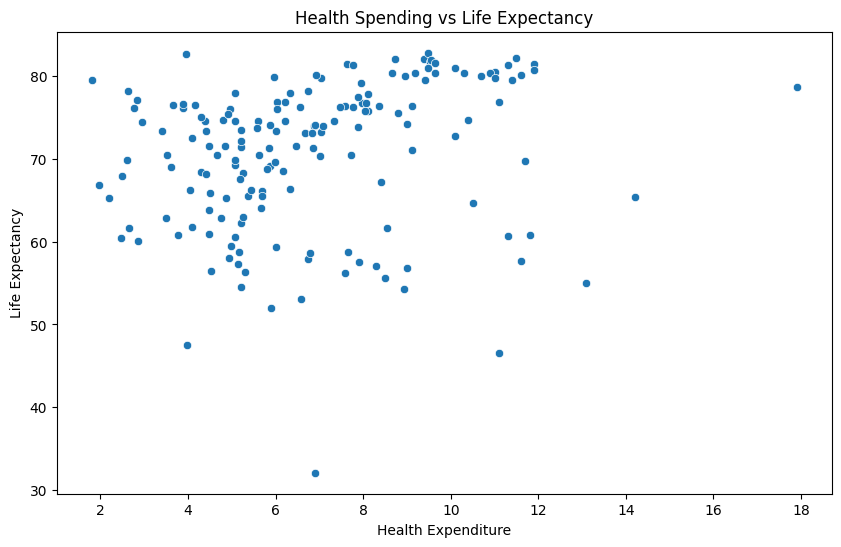

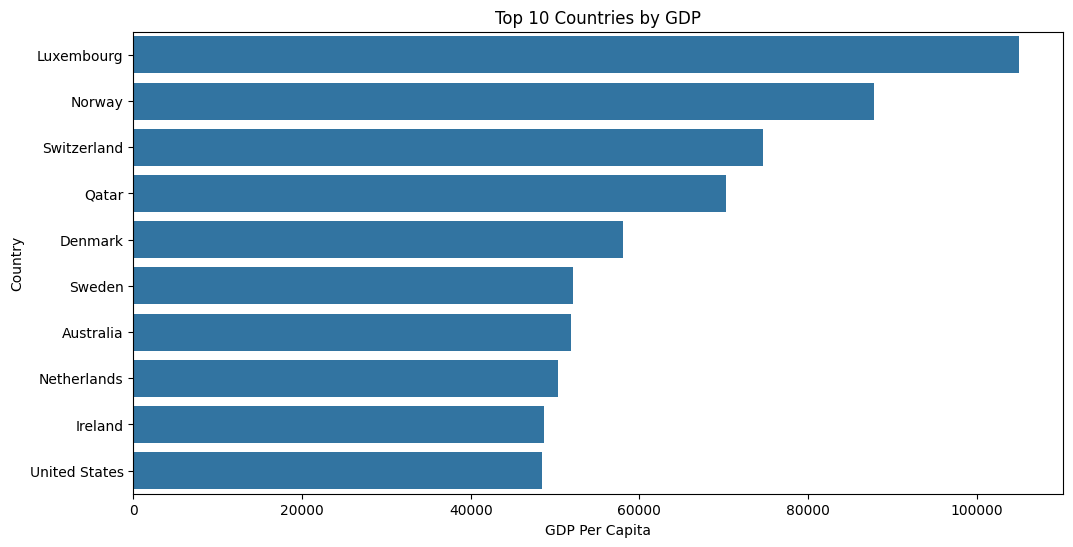

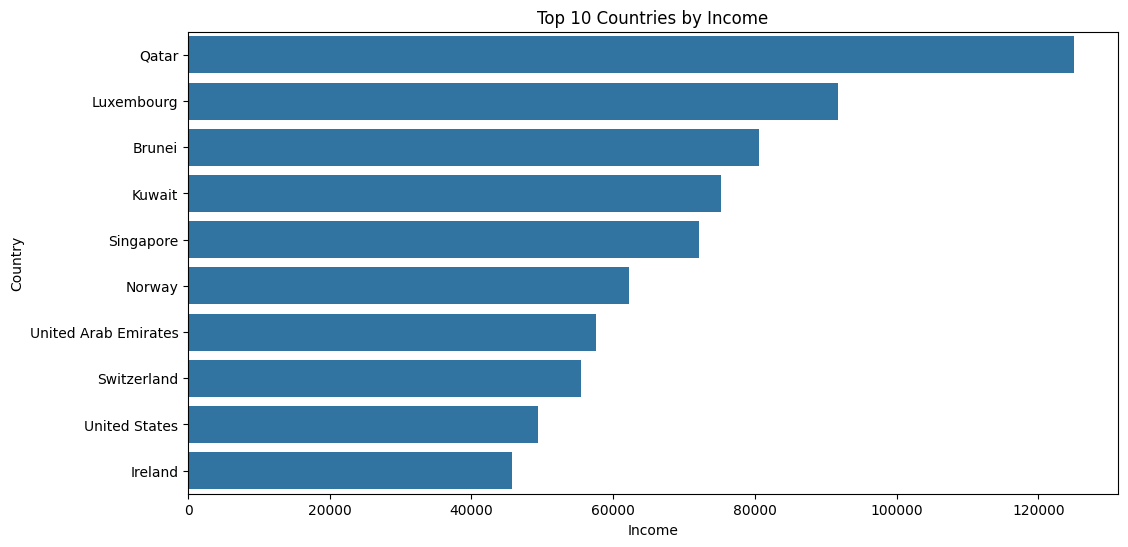

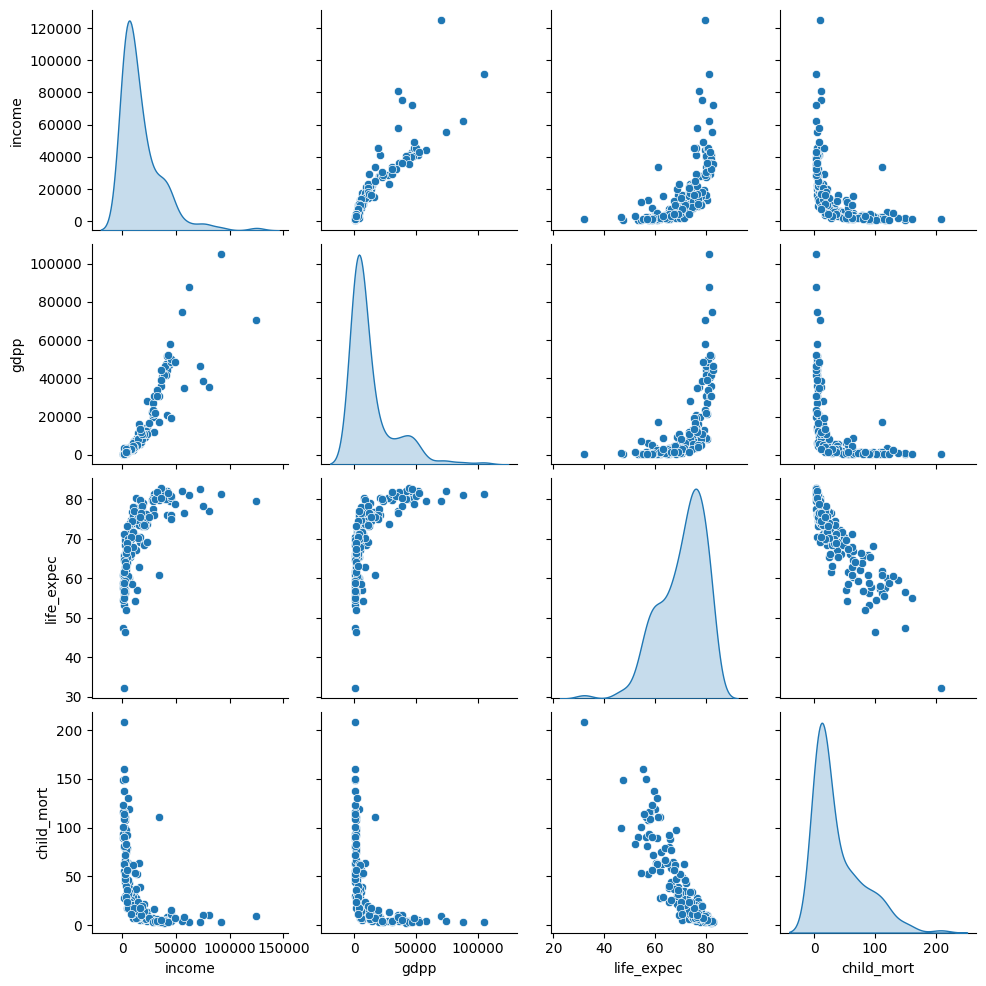

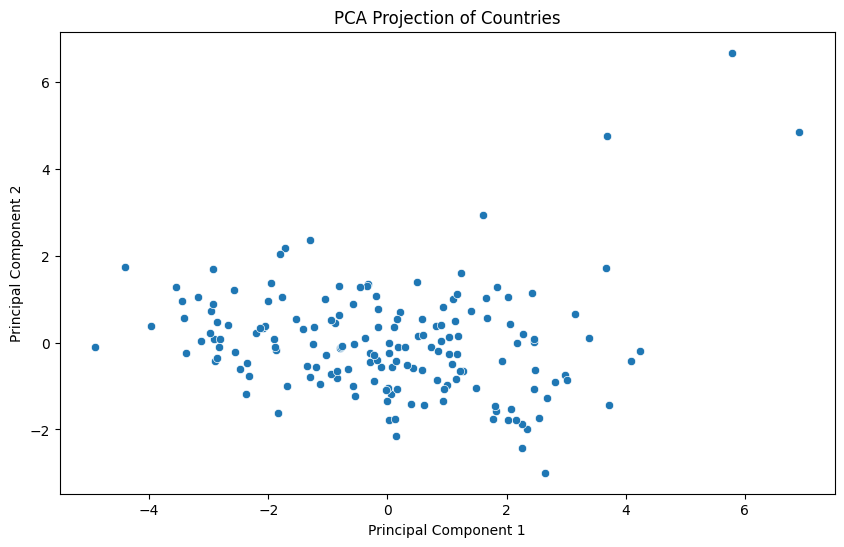


Explained Variance Ratio
[0.4595174  0.17181626]

Total Variance Explained: 0.6313336543771411


In [ ]:
# CORRELATION HEATMAP

plt.figure(figsize=(12,8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()

# HISTOGRAMS
X.hist(
    figsize=(15,10),
    bins=20
)
plt.suptitle(
    "Feature Distributions"
)
plt.show()

# BOXPLOTS
for col in numerical_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(
        x=df[col]
    )
    plt.title(f"Outlier Detection : {col}")
    plt.show()

# INCOME VS GDP
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='income',
    y='gdpp'
)
plt.title("Income vs GDP")
plt.xlabel("Income")
plt.ylabel("GDP Per Capita")
plt.show()

# CHILD MORTALITY VS LIFE EXPECTANCY
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='child_mort',
    y='life_expec'
)
plt.title("Child Mortality vs Life Expectancy")
plt.xlabel("Child Mortality")
plt.ylabel("Life Expectancy")
plt.show()

# HEALTH VS LIFE EXPECTANCY
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='health',
    y='life_expec'
)
plt.title("Health Spending vs Life Expectancy")
plt.xlabel("Health Expenditure")
plt.ylabel("Life Expectancy")
plt.show()

# TOP 10 COUNTRIES BY GDP
top_gdp = (
    df.sort_values(
        by='gdpp',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_gdp,
    x='gdpp',
    y='country'
)

plt.title("Top 10 Countries by GDP")
plt.xlabel("GDP Per Capita")
plt.ylabel("Country")
plt.show()

# TOP 10 COUNTRIES BY INCOME
top_income = (
    df.sort_values(
        by='income',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_income,
    x='income',
    y='country'
)

plt.title("Top 10 Countries by Income")
plt.xlabel("Income")
plt.ylabel("Country")
plt.show()

# PAIRPLOT

important_cols = [
    'income',
    'gdpp',
    'life_expec',
    'child_mort'
]
sns.pairplot(
    df[important_cols],
    diag_kind='kde'
)
plt.show()

# PCA VISUALIZATION
pca = PCA(
    n_components=2,
    random_state=42
)
X_pca = pca.fit_transform(X_processed)
pca_df = pd.DataFrame({

    'PC1': X_pca[:,0],

    'PC2': X_pca[:,1]

})
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2'
)

plt.title("PCA Projection of Countries")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("\nExplained Variance Ratio")
print(
    pca.explained_variance_ratio_
)
print(
    "\nTotal Variance Explained:",
    np.sum(
        pca.explained_variance_ratio_
    )
)


Feature Scaling

Scaled Data Statistics


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,-3.722904e-17,1.003008,-0.887138,-0.746619,-0.471798,0.592667,4.221297
exports,167.0,2.127373e-16,1.003008,-1.500192,-0.633337,-0.223528,0.374720,5.813835
health,167.0,5.504579e-16,1.003008,-1.827827,-0.692211,-0.181001,0.651541,4.047436
imports,167.0,2.765585e-16,1.003008,-1.939940,-0.691479,-0.148743,0.491353,5.266181
income,167.0,-7.977650e-17,1.003008,-0.860326,-0.717456,-0.373808,0.294237,5.611542
inflation,167.0,-1.063687e-17,1.003008,-1.137852,-0.566641,-0.226950,0.281636,9.129718
life_expec,167.0,3.696311e-16,1.003008,-4.337186,-0.592758,0.286958,0.704258,1.380962
total_fer,167.0,3.044803e-16,1.003008,-1.191250,-0.763902,-0.356431,0.617525,3.009349
gdpp,167.0,5.850277e-17,1.003008,-0.696801,-0.636660,-0.454431,0.059421,5.036507



 [0.4595174  0.17181626 0.13004259 0.11053162 0.07340211 0.02484235
 0.0126043  0.00981282 0.00743056]
        PC1       PC2
0 -2.913025  0.095621
1  0.429911 -0.588156
2 -0.285225 -0.455174
3 -2.932423  1.695555
4  1.033576  0.136659


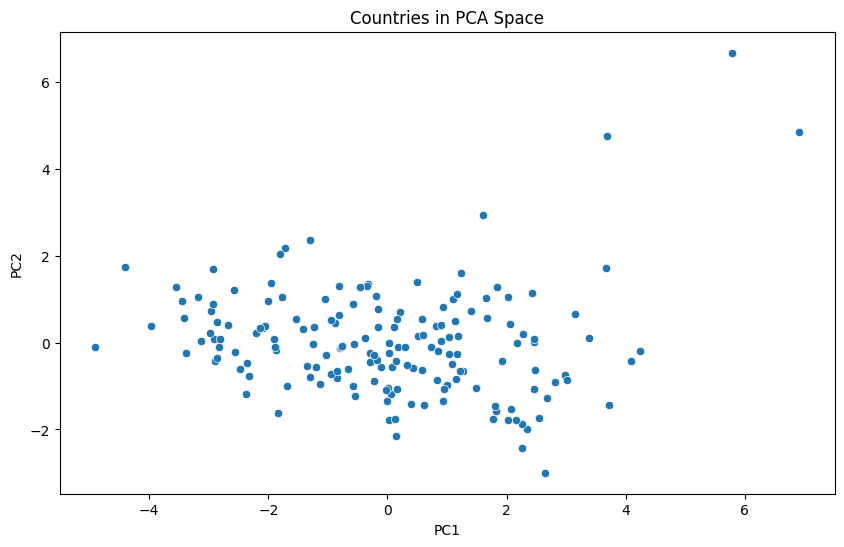

In [ ]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
print("Scaled Data Statistics")
display(
    scaled_df.describe().T
)

# PCA ANALYSIS
from sklearn.decomposition import PCA
pca_full = PCA()
pca_full.fit(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
print('\n',explained_variance)

# PCA REDUCTION
pca = PCA(
    n_components=2,
    random_state=42
)
X_pca = pca.fit_transform(
    X_scaled
)
pca_df = pd.DataFrame({

    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})
print(pca_df.head())

# PCA VISUALIZATION

plt.figure(figsize=(10,6))
sns.scatterplot(

    x=pca_df["PC1"],
    y=pca_df["PC2"]

)
plt.title( "Countries in PCA Space")
plt.show()

K-Means Clustering

Cluster
2    84
1    47
0    36
Name: count, dtype: int64


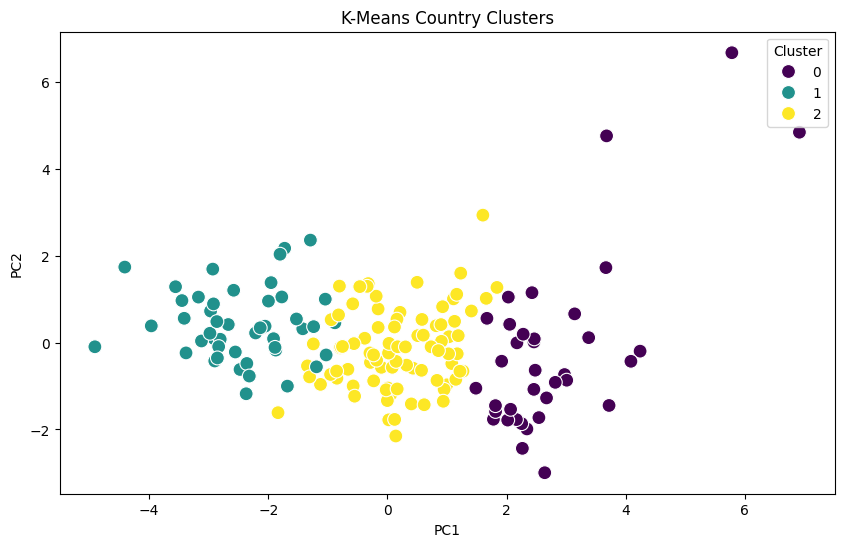



CLUSTER 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland'] 



CLUSTER 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea'] 



CLUSTER 2
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil'] 



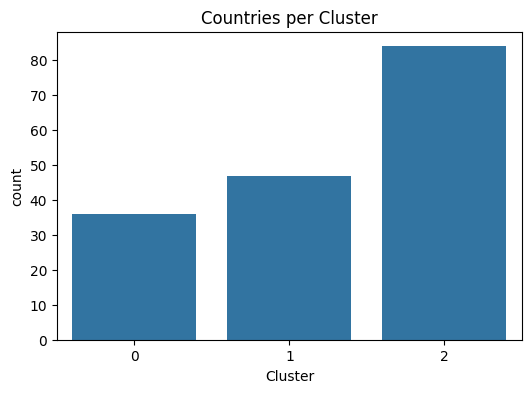

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df['Cluster'].value_counts())


cluster_names = {
    0:"Developed",
    1:"Developing",
    2:"Underdeveloped"
}
df['Segment'] = df[
    'Cluster'
].map(cluster_names)

# PCA CLUSTER VISUALIZATION

pca_df['Cluster'] = clusters
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=100
)
plt.title("K-Means Country Clusters")
plt.show()

# COUNTRIES IN EACH CLUSTER


for cluster in sorted(df['Cluster'].unique()):
    print("\n")
    print(f"CLUSTER {cluster}")
    print(
        df[df['Cluster']==cluster]['country']
        .head(15)
        .tolist(),'\n'
    )


# CLUSTER DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(
    x='Cluster',
    data=df
)
plt.title("Countries per Cluster")
plt.show()



Importing DBSCAN

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


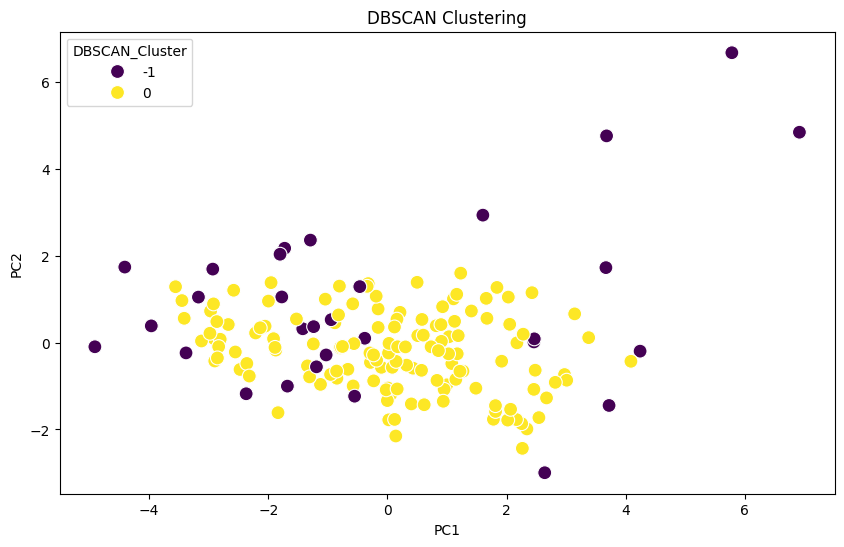

Number of Outliers: 30


,country
3,Angola
23,Brunei
31,Central African Republic
37,"Congo, Dem. Rep."
38,"Congo, Rep."
49,Equatorial Guinea
55,Gabon
66,Haiti
72,Iraq
73,Ireland


DBSCAN_Cluster,-1,0
Cluster,,
0,9,27
1,16,31
2,5,79


In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

df['DBSCAN_Cluster'] = dbscan_labels

print(
    df['DBSCAN_Cluster']
    .value_counts()
)

# DBSCAN VISUALIZATION

pca_df['DBSCAN_Cluster'] = dbscan_labels
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,

    x='PC1',
    y='PC2',

    hue='DBSCAN_Cluster',
    palette='viridis',
    s=100

)

plt.title("DBSCAN Clustering")
plt.show()


# OUTLIERS DETECTED
noise_points = df[
    df['DBSCAN_Cluster'] == -1
]
print(
    "Number of Outliers:",
    len(noise_points)
)
display(
    noise_points[['country']]
)


# COMPARISON
pd.crosstab(
    df['Cluster'],
    df['DBSCAN_Cluster']
)

Random Forest


(167, 9)
(167,)
(133, 9)
(34, 9)
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



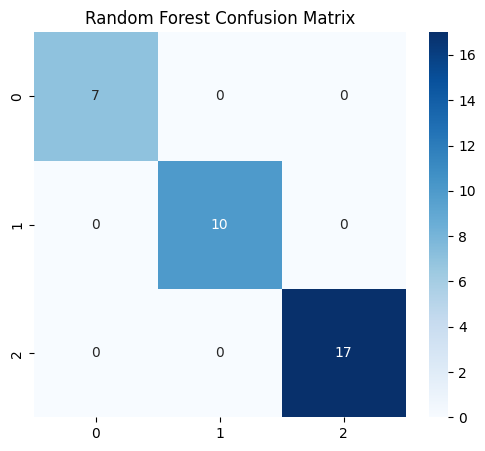

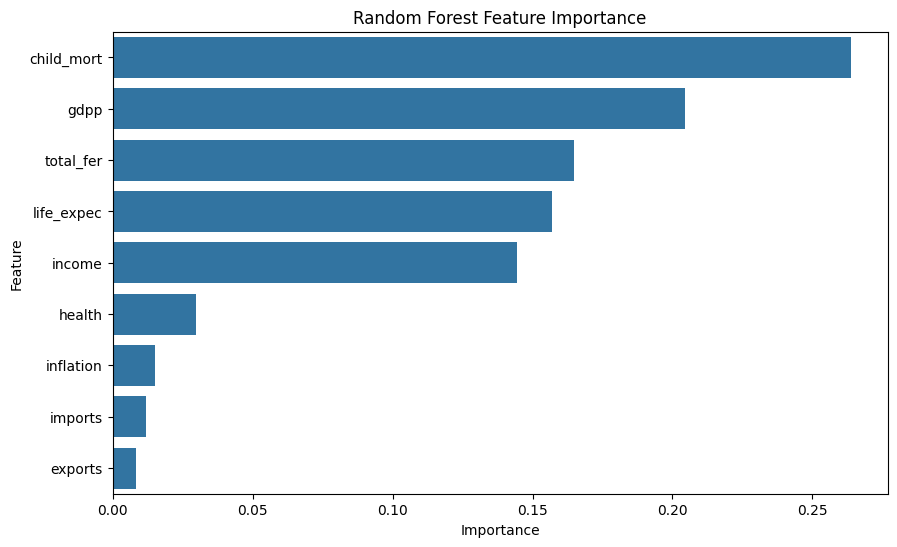

,Feature,Importance
0,child_mort,0.263621
8,gdpp,0.204599
7,total_fer,0.164964
6,life_expec,0.156915
4,income,0.144410
2,health,0.029911
5,inflation,0.015248
3,imports,0.011961
1,exports,0.008371


In [ ]:
# FEATURES AND TARGET

X = df.drop(
    columns=[
        'country',
        'Cluster',
        'DBSCAN_Cluster',
        'Segment'
    ]
)

y = df['Cluster']
print(X.shape)
print(y.shape)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42,
    stratify=y

)

print(X_train.shape)
print(X_test.shape)

# RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)
print(
    classification_report(
        y_test,
        rf_pred
    )
)

plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(
        y_test,
        rf_pred
    ),
    annot=True,
    cmap='Blues',
    fmt='d'
)
plt.title(
    "Random Forest Confusion Matrix"
)
plt.show()

# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
        rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title(
    "Random Forest Feature Importance"
)
plt.show()

display(
    importance
)

XGBoost

Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



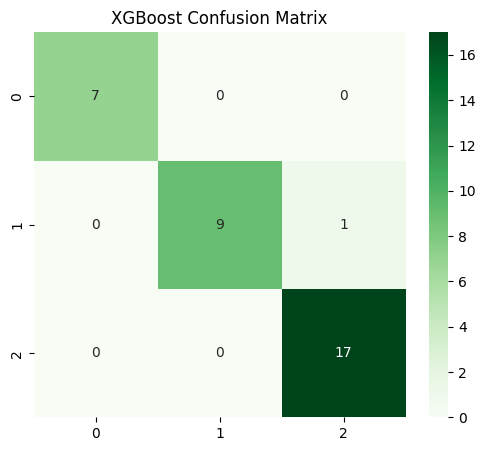

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        xgb_pred
    )
)
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(
        y_test,
        xgb_pred
    ),
    annot=True,
    cmap='Greens',
    fmt='d'
)
plt.title(
    "XGBoost Confusion Matrix"
)
plt.show()

Cross Validation

In [ ]:
cv_scores = cross_val_score(
    rf, X, y, cv=5,scoring='accuracy'
)

print(
    "CV Scores:",
    cv_scores
)

print(
    "Mean CV Score:",
    cv_scores.mean()
)

CV Scores: [0.97058824 1.         0.93939394 0.90909091 0.96969697]
Mean CV Score: 0.9577540106951872


HyperParameter Tuning

In [ ]:
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10]
}
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

# MODEL COMPARISON

comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(
            y_test,
            rf_pred
        ),
        accuracy_score(
            y_test,
            xgb_pred
        )
    ]
})
display(comparison)


{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
0.9467236467236468


,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,0.970588
